<a href="https://colab.research.google.com/github/suryanshshah2006/complete-triplet-bilstm-sleep-staging/blob/main/Zan_EEG_Sleep_Stage_Classification(Subject_Split).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install scipy scikit-learn seaborn
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm.notebook import tqdm
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
import seaborn as sns
import matplotlib.pyplot as plt

Mounted at /content/drive


In [2]:
SOURCE_DIR = '/content/drive/MyDrive/EEG_Full_58_Subjects'
MASTER_CSV = '/content/drive/MyDrive/EEG_Full_58_Subjects/master_labels_clean.csv'
LOCAL_DIR = '/content/local_eeg_data'
MODEL_DIR = '/content/drive/MyDrive/eeg_bilstm_complete_triplets'
os.makedirs(MODEL_DIR, exist_ok=True)
CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
SPLIT_COL = 'split_subject_level'   # this notebook = subject-level only

In [3]:
if not os.path.exists(LOCAL_DIR):
    print("Unzipping calibrated data into Colab local runtime...")
    shutil.unpack_archive('/content/drive/MyDrive/Zan_EEG_128Hz_Epochs_CALIBRATED.zip', LOCAL_DIR)
    print("Local data restored!")

print("Building subject-wise epoch indexer...")

labels_df = pd.read_csv(MASTER_CSV)
labels_df = labels_df[['subject', 'seg_idx', 'label', 'label_code', 'exists']]

files = [f for f in os.listdir(LOCAL_DIR) if f.endswith('.npy')]
file_df = pd.DataFrame({'filename': files})
file_df['subject'] = file_df['filename'].apply(lambda x: x.split('_seg_')[0])
file_df['seg_idx'] = file_df['filename'].apply(lambda x: int(x.split('_seg_')[1].replace('.npy', '')))
file_df['filepath'] = os.path.join(LOCAL_DIR, '') + file_df['filename']

master_df = pd.merge(file_df, labels_df, on=['subject', 'seg_idx'], how='inner')
master_df = master_df.sort_values(by=['subject', 'seg_idx']).reset_index(drop=True)

print("Rows:", len(master_df))
print("Subjects:", master_df['subject'].nunique())

sample_arr = np.load(master_df.iloc[0]['filepath'])
EPOCH_LEN = sample_arr.shape[1]
N_CHANNELS = sample_arr.shape[0]
print(f"Detected shape: {N_CHANNELS} channels x {EPOCH_LEN} samples")

Unzipping calibrated data into Colab local runtime...
Local data restored!
Building subject-wise epoch indexer...
Rows: 47090
Subjects: 52
Detected shape: 24 channels x 3840 samples


In [4]:
master_df['epoch_rank'] = master_df.groupby('subject').cumcount()

train_e_idx, val_e_idx = train_test_split(
    master_df.index, test_size=0.2, random_state=42, stratify=master_df['label_code']
)
master_df['split_epoch_level'] = 'train'
master_df.loc[val_e_idx, 'split_epoch_level'] = 'val'

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_s_idx, val_s_idx = next(gss.split(master_df, groups=master_df['subject']))
master_df['split_subject_level'] = 'train'
master_df.loc[val_s_idx, 'split_subject_level'] = 'val'

assert len(set(master_df.loc[train_s_idx,'subject']) & set(master_df.loc[val_s_idx,'subject'])) == 0
print(f"[{SPLIT_COL}] Train: {(master_df[SPLIT_COL]=='train').sum()}  Val: {(master_df[SPLIT_COL]=='val').sum()}")
print(f"Held-out val subjects: {sorted(master_df.loc[val_s_idx,'subject'].unique())}")

[split_subject_level] Train: 36903  Val: 10187
Held-out val subjects: ['sub-06', 'sub-09', 'sub-17', 'sub-18', 'sub-24', 'sub-26', 'sub-41', 'sub-53', 'sub-58', 'sub-62', 'sub-65']


In [5]:
lookup = master_df.set_index(['subject', 'epoch_rank'])
triplet_rows = []
for _, row in master_df.iterrows():
    sub, rank = row['subject'], int(row['epoch_rank'])
    try:
        prev_row = lookup.loc[(sub, rank - 1)]
        curr_row = lookup.loc[(sub, rank)]
        next_row = lookup.loc[(sub, rank + 1)]
        if isinstance(prev_row, pd.DataFrame): prev_row = prev_row.iloc[0]
        if isinstance(curr_row, pd.DataFrame): curr_row = curr_row.iloc[0]
        if isinstance(next_row, pd.DataFrame): next_row = next_row.iloc[0]
        if not (int(prev_row['seg_idx']) + 1 == int(curr_row['seg_idx']) and
                int(curr_row['seg_idx']) + 1 == int(next_row['seg_idx'])):
            continue
        triplet_rows.append({
            'subject': sub, 'epoch_rank': rank, 'seg_idx': int(curr_row['seg_idx']),
            'filepath_prev': prev_row['filepath'], 'filepath_curr': curr_row['filepath'],
            'filepath_next': next_row['filepath'],
            'label_code': int(curr_row['label_code']),
            'split_epoch_level': curr_row['split_epoch_level'],
            'split_subject_level': curr_row['split_subject_level'],
        })
    except KeyError:
        continue

triplet_df = pd.DataFrame(triplet_rows).sort_values(['subject', 'seg_idx']).reset_index(drop=True)
print("Complete triplet samples:", len(triplet_df))
print(triplet_df['label_code'].value_counts().sort_index())

Complete triplet samples: 46928
label_code
0     6295
1     5913
2    21933
3     5883
4     6904
Name: count, dtype: int64


In [6]:
class CompleteTripletGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, shuffle=True, n_classes=5, **kwargs):
        super().__init__(**kwargs)
        self.df = df.reset_index(drop=True).copy()
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n_classes = n_classes
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index + 1) * self.batch_size, len(self.df))
        batch_df = self.df.iloc[self.indices[start:end]]
        X_batch, y_batch = [], []
        for _, row in batch_df.iterrows():
            X_prev = np.load(row['filepath_prev']).astype(np.float32)
            X_curr = np.load(row['filepath_curr']).astype(np.float32)
            X_next = np.load(row['filepath_next']).astype(np.float32)
            X_context = np.concatenate([X_prev, X_curr, X_next], axis=-1)
            mean = X_context.mean(axis=1, keepdims=True)
            std = X_context.std(axis=1, keepdims=True)
            X_context = (X_context - mean) / (std + 1e-8)
            X_batch.append(X_context)
            y_batch.append(row['label_code'])
        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = to_categorical(np.array(y_batch), num_classes=self.n_classes)
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [7]:
def build_triplet_model(input_shape):
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Permute((2, 1))(inp)
    s1 = tf.keras.layers.Conv1D(32, 32, strides=4, activation='relu', padding='same')(x)
    s2 = tf.keras.layers.Conv1D(32, 128, strides=4, activation='relu', padding='same')(x)
    f = tf.keras.layers.Concatenate()([s1, s2])
    f = tf.keras.layers.BatchNormalization()(f)
    f = tf.keras.layers.MaxPooling1D(4)(f)
    f = tf.keras.layers.Dropout(0.3)(f)
    f = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(f)
    a = tf.keras.layers.Attention()([f, f])
    a = tf.keras.layers.GlobalAveragePooling1D()(a)
    d = tf.keras.layers.Dense(64, activation='relu')(a)
    out = tf.keras.layers.Dense(5, activation='softmax')(d)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                   loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                   metrics=['accuracy'])
    return model

test_model = build_triplet_model((N_CHANNELS, EPOCH_LEN*3))
test_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 11520) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 11520, 24) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2880, 32)  │     24,608 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2880, 32)  │     98,336 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2880, 64)  │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2880, 64)  │        256 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 720, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 720, 64)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 720, 128)  │     66,048 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 720, 128)  │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 197,829 (772.77 KB)

 Trainable params: 197,701 (772.27 KB)

 Non-trainable params: 128 (512.00 B)

In [8]:
def train_and_eval_resumable(gen_cls, df, split_col, model_builder, model_name, epochs=30):
    train_df = df[df[split_col] == 'train'].reset_index(drop=True)
    val_df   = df[df[split_col] == 'val'].reset_index(drop=True)
    print(f"[{model_name} | {split_col}] Train: {len(train_df)}  Val: {len(val_df)}")

    train_gen = gen_cls(train_df, batch_size=32, shuffle=True)
    val_gen   = gen_cls(val_df, batch_size=32, shuffle=False)

    ckpt_path = os.path.join(MODEL_DIR, f"{model_name}_{split_col}.keras")
    log_path  = os.path.join(MODEL_DIR, f"{model_name}_{split_col}_log.csv")

    initial_epoch = 0
    if os.path.exists(ckpt_path):
        print(f"Found existing checkpoint — resuming: {ckpt_path}")
        model = tf.keras.models.load_model(ckpt_path)
        if os.path.exists(log_path):
            prev_log = pd.read_csv(log_path)
            initial_epoch = len(prev_log)
            print(f"Resuming from epoch {initial_epoch}")
    else:
        model = model_builder()

    callbacks = [
        ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
        CSVLogger(log_path, append=True),
    ]

    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs,
                          initial_epoch=initial_epoch, callbacks=callbacks, verbose=1)

    best_model = tf.keras.models.load_model(ckpt_path)
    y_true, y_pred, all_probs = [], [], []
    for i in range(len(val_gen)):
        Xb, yb = val_gen[i]
        preds = best_model.predict(Xb, verbose=0)
        all_probs.append(preds)
        y_true.extend(np.argmax(yb, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    probs_all = np.concatenate(all_probs, axis=0)

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True)
    print(f"[{model_name} | {split_col}] Val Accuracy: {acc:.4f}")
    return {'model': model_name, 'split': split_col, 'accuracy': acc,
            'macro_f1': report['macro avg']['f1-score'], 'history': history, 'report': report,
            'ckpt_path': ckpt_path, 'y_true': y_true, 'y_pred': y_pred, 'probs': probs_all,
            'val_df': val_df}

In [9]:
result_subject = train_and_eval_resumable(
    CompleteTripletGenerator, triplet_df, SPLIT_COL,
    lambda: build_triplet_model((N_CHANNELS, EPOCH_LEN*3)),
    'YourModel_Triplet', epochs=30
)

[YourModel_Triplet | split_subject_level] Train: 36763  Val: 10165
Epoch 1/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.7033 - loss: 0.9542
Epoch 1: val_accuracy improved from None to 0.72209, saving model to /content/drive/MyDrive/eeg_bilstm_complete_triplets/YourModel_Triplet_split_subject_level.keras

Epoch 1: finished saving model to /content/drive/MyDrive/eeg_bilstm_complete_triplets/YourModel_Triplet_split_subject_level.keras
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 488s 415ms/step - accuracy: 0.7712 - loss: 0.8305 - val_accuracy: 0.7221 - val_loss: 0.9711 - learning_rate: 5.0000e-04
Epoch 2/30
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.8217 - loss: 0.7360
Epoch 2: val_accuracy improved from 0.72209 to 0.72523, saving model to /content/drive/MyDrive/eeg_bilstm_complete_triplets/YourModel_Triplet_split_subject_level.keras

Epoch 2: finished saving model to /content/drive/MyDrive/eeg_bilstm_complete_triplets/YourModel_Triplet_split_subject_level.keras
1149/11


FULL REPORT: YourModel_Triplet | split_subject_level
              precision    recall  f1-score   support

        Wake     0.6649    0.7571    0.7080      1478
          N1     0.4770    0.4371    0.4562      1400
          N2     0.7754    0.7921    0.7836      4593
          N3     0.6836    0.6891    0.6863      1116
         REM     0.8929    0.7820    0.8338      1578

    accuracy                         0.7252     10165
   macro avg     0.6987    0.6915    0.6936     10165
weighted avg     0.7264    0.7252    0.7246     10165



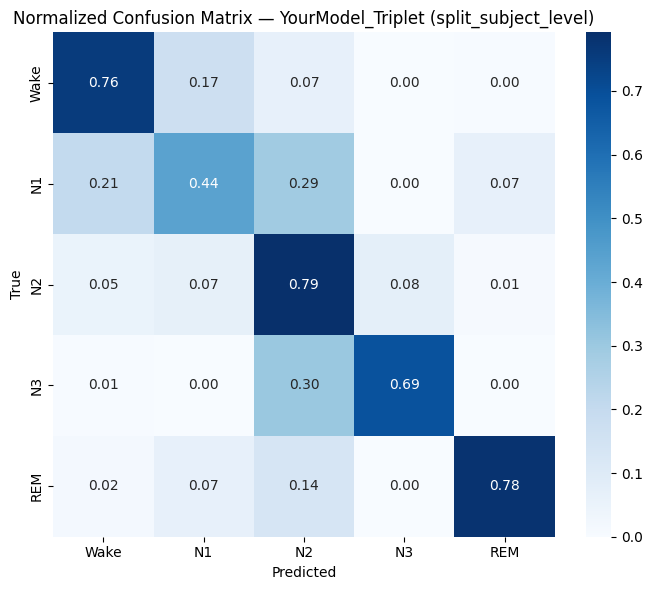

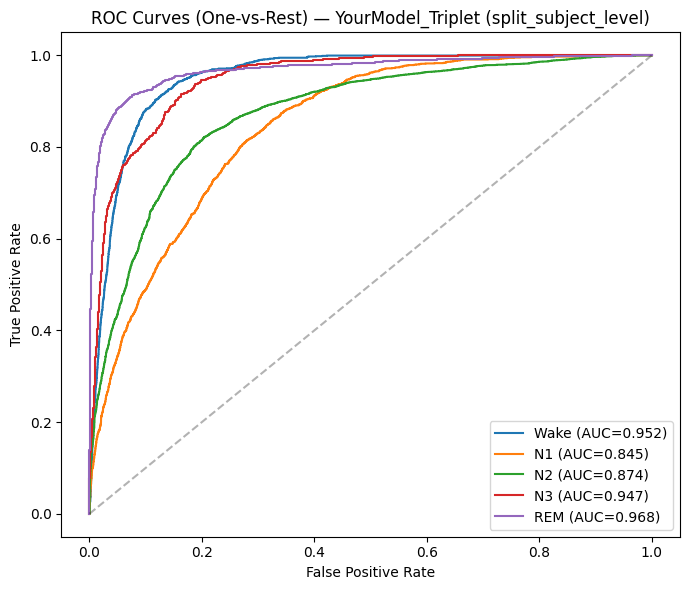

Wake: most prominent channel = Ch22 | score = 0.0576


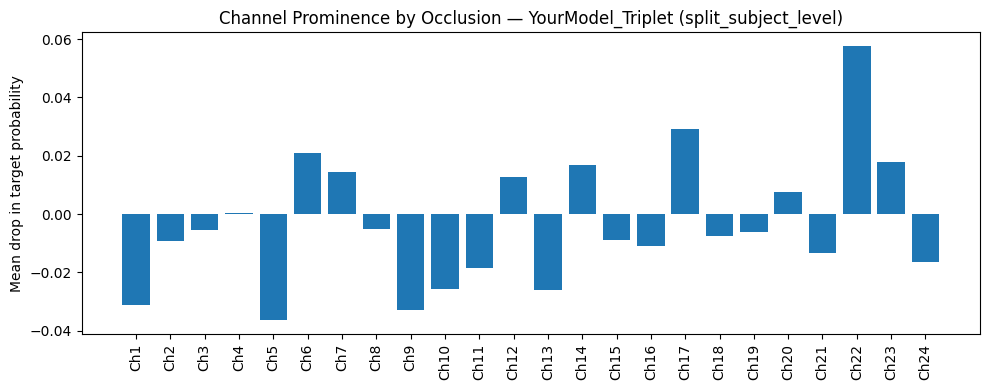

N1: most prominent channel = Ch21 | score = 0.1430


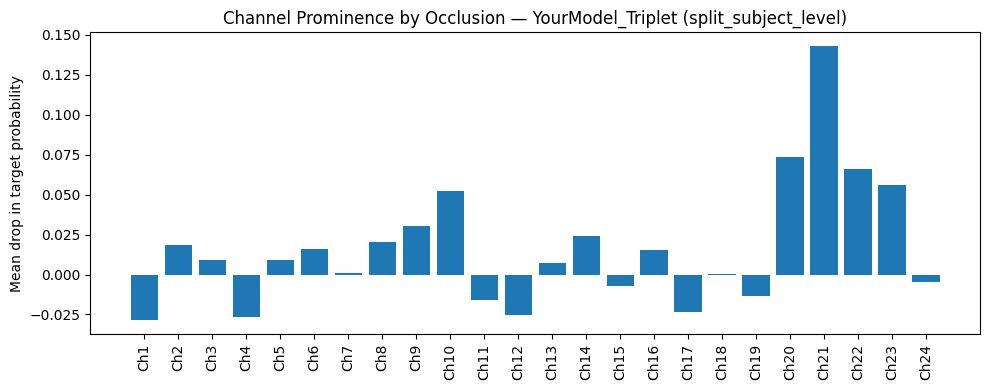

N2: most prominent channel = Ch8 | score = 0.0778


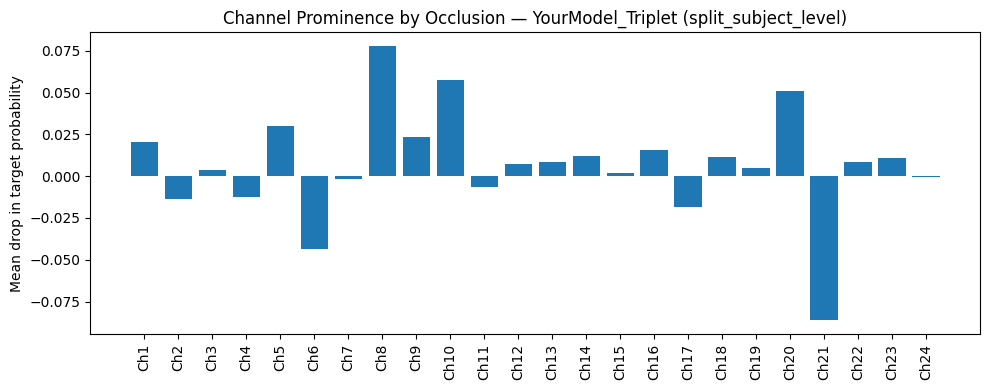

N3: most prominent channel = Ch21 | score = 0.0936


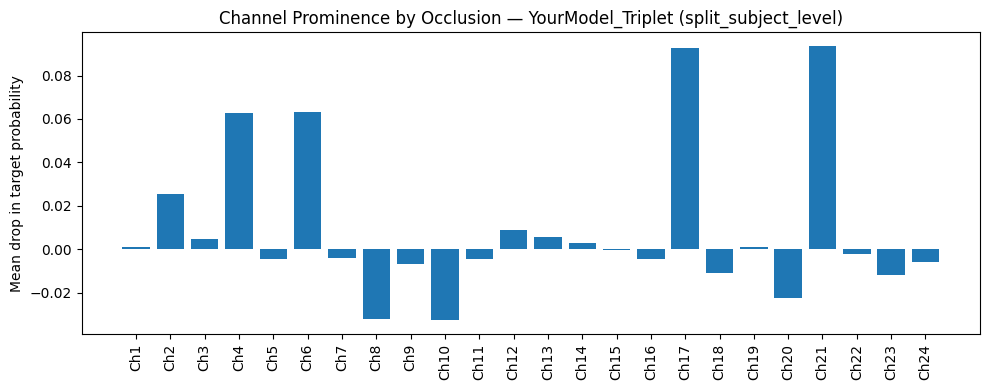

REM: most prominent channel = Ch20 | score = 0.1439


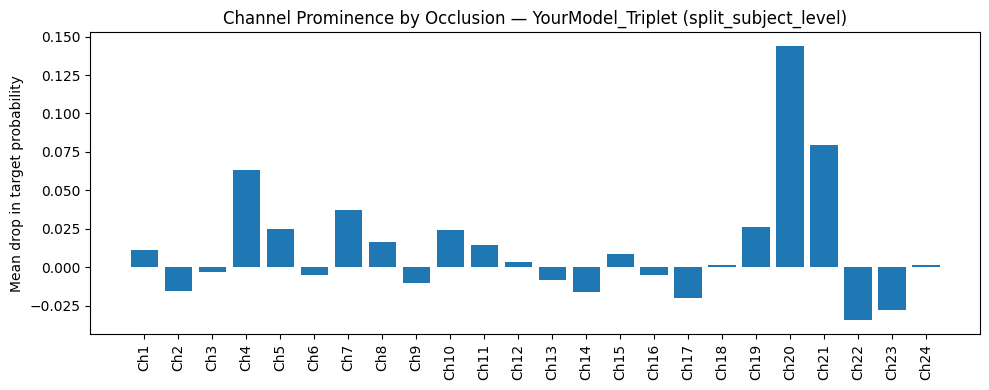

Wake: most prominent band = Delta (0.5-4 Hz) | score = 0.108268


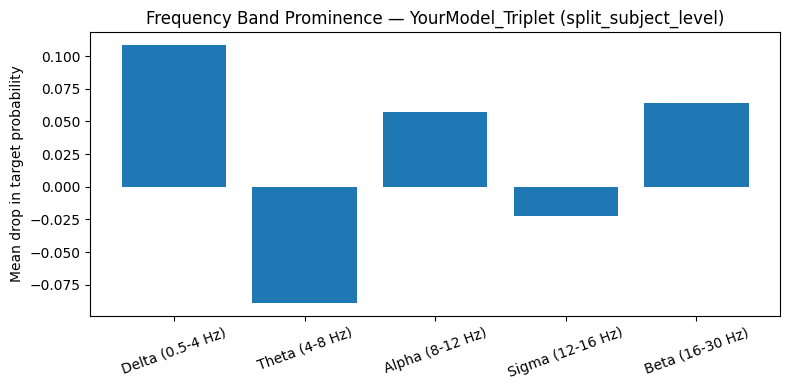

N1: most prominent band = Theta (4-8 Hz) | score = 0.212325


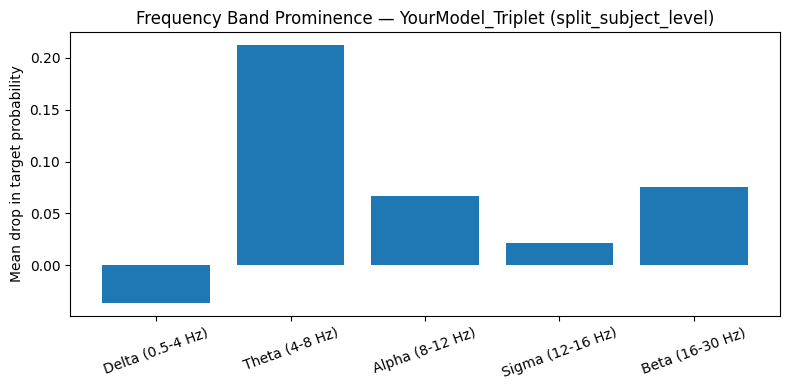

N2: most prominent band = Delta (0.5-4 Hz) | score = 0.678850


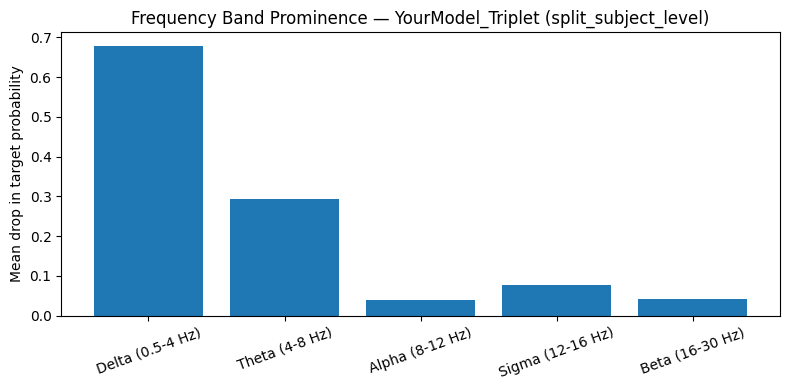

N3: most prominent band = Delta (0.5-4 Hz) | score = 0.895687


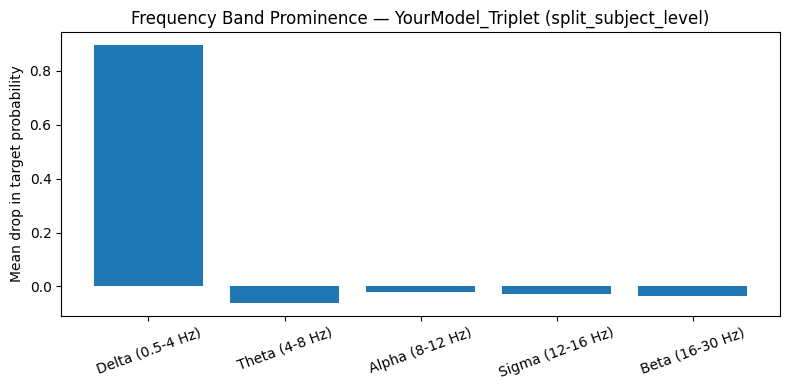

REM: most prominent band = Delta (0.5-4 Hz) | score = 0.501297


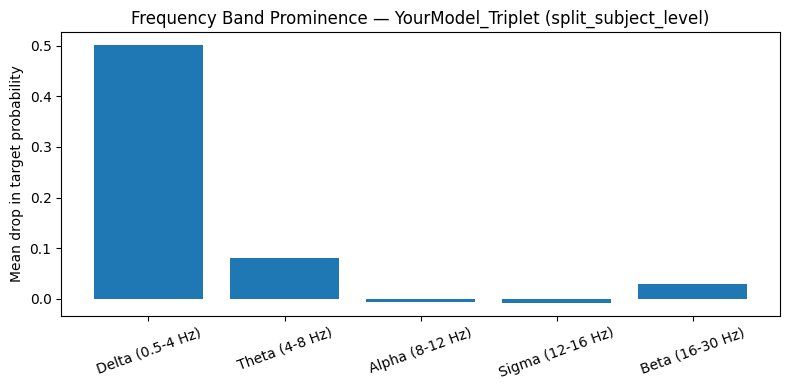

In [10]:
def full_triplet_report(result):
    model_name, split_col = result['model'], result['split']
    y_true, y_pred, probs_all = result['y_true'], result['y_pred'], result['probs']
    print(f"\n{'='*70}\nFULL REPORT: {model_name} | {split_col}\n{'='*70}")

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(7,6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Normalized Confusion Matrix — {model_name} ({split_col})")
    plt.tight_layout(); plt.show()

    y_true_bin = label_binarize(y_true, classes=list(range(5)))
    plt.figure(figsize=(7,6))
    for i, cname in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs_all[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'k--',alpha=0.3)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves (One-vs-Rest) — {model_name} ({split_col})")
    plt.legend(); plt.tight_layout(); plt.show()

    def load_triplet_batch(df_subset):
        X_batch = []
        for _, row in df_subset.iterrows():
            X_prev = np.load(row['filepath_prev']).astype(np.float32)
            X_curr = np.load(row['filepath_curr']).astype(np.float32)
            X_next = np.load(row['filepath_next']).astype(np.float32)
            X_context = np.concatenate([X_prev, X_curr, X_next], axis=-1)
            mean = X_context.mean(axis=1, keepdims=True)
            std = X_context.std(axis=1, keepdims=True)
            X_context = (X_context - mean) / (std + 1e-8)
            X_batch.append(X_context)
        return np.array(X_batch, dtype=np.float32)

    best_model = tf.keras.models.load_model(result['ckpt_path'])
    val_df_reset = result['val_df'].reset_index(drop=True)
    channel_names = [f'Ch{i+1}' for i in range(N_CHANNELS)]

    def channel_occlusion_importance(model, X_subset, class_idx, batch_size=32):
        baseline_probs = model.predict(X_subset, batch_size=batch_size, verbose=0)[:, class_idx]
        drops = []
        for ch in range(X_subset.shape[1]):
            X_occ = X_subset.copy()
            X_occ[:, ch, :] = 0.0
            occ_probs = model.predict(X_occ, batch_size=batch_size, verbose=0)[:, class_idx]
            drops.append((baseline_probs - occ_probs).mean())
            del X_occ
        return np.array(drops)

    stage_channel_results = {}
    for class_idx, class_name in enumerate(CLASS_NAMES):
        mask = (y_true == class_idx) & (y_pred == class_idx)
        idx_subset = np.where(mask)[0][:200]
        if len(idx_subset) == 0:
            print(f"No correctly predicted samples for {class_name}")
            continue
        X_subset = load_triplet_batch(val_df_reset.iloc[idx_subset])

        imp = channel_occlusion_importance(best_model, X_subset, class_idx)
        stage_channel_results[class_name] = imp
        most_prominent_idx = int(np.argmax(imp))
        print(f"{class_name}: most prominent channel = {channel_names[most_prominent_idx]} | score = {imp[most_prominent_idx]:.4f}")
        plt.figure(figsize=(10,4))
        plt.bar(channel_names, imp)
        plt.xticks(rotation=90)
        plt.title(f'Channel Prominence by Occlusion — {model_name} ({split_col})')
        plt.ylabel('Mean drop in target probability')
        plt.tight_layout(); plt.show()

        del X_subset
        gc.collect()

    FS = EPOCH_LEN / 30.0
    band_defs = {
        'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8),
        'Alpha (8-12 Hz)': (8, 12), 'Sigma (12-16 Hz)': (12, 16),
        'Beta (16-30 Hz)': (16, 30),
    }
    def bandstop(X, low, high, fs=FS, order=4):
        b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='bandstop')
        return filtfilt(b, a, X, axis=-1)

    def band_occlusion_importance(model, X_subset, class_idx):
        baseline_probs = model.predict(X_subset, batch_size=32, verbose=0)[:, class_idx]
        results_ = {}
        for band_name, (low, high) in band_defs.items():
            X_muted = bandstop(X_subset, low, high)
            muted_probs = model.predict(X_muted, batch_size=32, verbose=0)[:, class_idx]
            results_[band_name] = (baseline_probs - muted_probs).mean()
            del X_muted
        return results_

    stage_band_results = {}
    for class_idx, class_name in enumerate(CLASS_NAMES):
        mask = (y_true == class_idx) & (y_pred == class_idx)
        idx_subset = np.where(mask)[0][:200]
        if len(idx_subset) == 0:
            continue
        X_subset = load_triplet_batch(val_df_reset.iloc[idx_subset])

        band_imp = band_occlusion_importance(best_model, X_subset, class_idx)
        stage_band_results[class_name] = band_imp
        best_band = max(band_imp, key=band_imp.get)
        print(f"{class_name}: most prominent band = {best_band} | score = {band_imp[best_band]:.6f}")
        plt.figure(figsize=(8,4))
        plt.bar(list(band_imp.keys()), list(band_imp.values()))
        plt.xticks(rotation=20)
        plt.title(f'Frequency Band Prominence — {model_name} ({split_col})')
        plt.ylabel('Mean drop in target probability')
        plt.tight_layout(); plt.show()

        del X_subset
        gc.collect()

    return {'stage_channel_results': stage_channel_results, 'stage_band_results': stage_band_results}

xai_subject = full_triplet_report(result_subject)


--- Global Band Sweep: YourModel_Triplet (split_subject_level) ---
Evaluating isolated band: Delta (0.5-4 Hz)
Delta (0.5-4 Hz): isolated-band accuracy = 0.1511
Evaluating isolated band: Theta (4-8 Hz)
Theta (4-8 Hz): isolated-band accuracy = 0.2024
Evaluating isolated band: Alpha (8-12 Hz)
Alpha (8-12 Hz): isolated-band accuracy = 0.1574
Evaluating isolated band: Sigma (12-16 Hz)
Sigma (12-16 Hz): isolated-band accuracy = 0.2404
Evaluating isolated band: Beta (16-30 Hz)
Beta (16-30 Hz): isolated-band accuracy = 0.1520


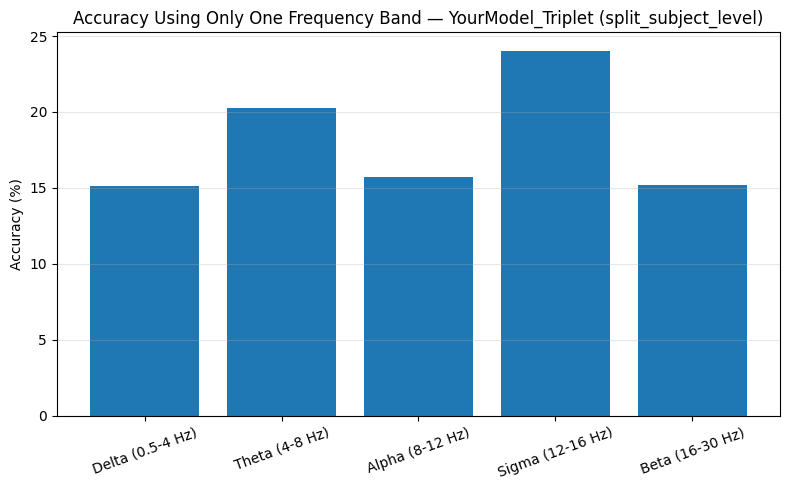

Evaluating muted band: Delta (0.5-4 Hz)
Delta (0.5-4 Hz): mute accuracy = 0.2832
Evaluating muted band: Theta (4-8 Hz)
Theta (4-8 Hz): mute accuracy = 0.6310
Evaluating muted band: Alpha (8-12 Hz)
Alpha (8-12 Hz): mute accuracy = 0.6999
Evaluating muted band: Sigma (12-16 Hz)
Sigma (12-16 Hz): mute accuracy = 0.7089
Evaluating muted band: Beta (16-30 Hz)
Beta (16-30 Hz): mute accuracy = 0.6931


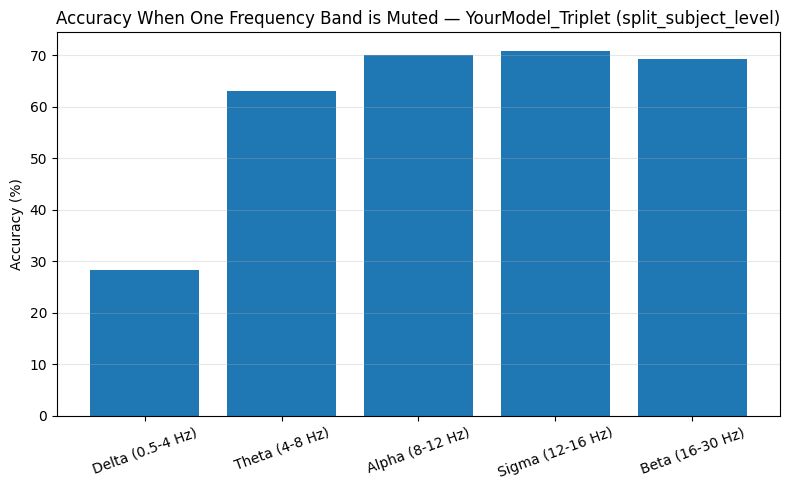

In [13]:
FS = EPOCH_LEN / 30.0
band_defs = {
    'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-12 Hz)': (8, 12), 'Sigma (12-16 Hz)': (12, 16),
    'Beta (16-30 Hz)': (16, 30),
}

def bandstop(X, low, high, fs=FS, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='bandstop')
    return filtfilt(b, a, X, axis=-1)

def load_triplet_batch(df_subset):
    X_batch = []
    for _, row in df_subset.iterrows():
        X_prev = np.load(row['filepath_prev']).astype(np.float32)
        X_curr = np.load(row['filepath_curr']).astype(np.float32)
        X_next = np.load(row['filepath_next']).astype(np.float32)
        X_context = np.concatenate([X_prev, X_curr, X_next], axis=-1)
        mean = X_context.mean(axis=1, keepdims=True)
        std = X_context.std(axis=1, keepdims=True)
        X_context = (X_context - mean) / (std + 1e-8)
        X_batch.append(X_context)
    return np.array(X_batch, dtype=np.float32)

best_model = tf.keras.models.load_model(result_subject['ckpt_path'])
val_df_reset = result_subject['val_df'].reset_index(drop=True)
model_name, split_col = result_subject['model'], result_subject['split']

def evaluate_with_band_transform(model, df_val, transform_fn, batch_size=32):
    y_t, y_p = [], []
    n = len(df_val)
    for start in range(0, n, batch_size):
        batch_df = df_val.iloc[start:start+batch_size]
        X_batch = load_triplet_batch(batch_df)
        if transform_fn is not None:
            X_batch = transform_fn(X_batch)
        preds = model.predict(X_batch, batch_size=batch_size, verbose=0)
        y_p.extend(np.argmax(preds, axis=1))
        y_t.extend(batch_df['label_code'].values)
        del X_batch
    return accuracy_score(y_t, y_p)

def bandpass(X, low, high, fs=FS, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, X, axis=-1)

print(f"\n--- Global Band Sweep: {model_name} ({split_col}) ---")

single_band_acc = {}
for band_name, (low, high) in band_defs.items():
    print(f"Evaluating isolated band: {band_name}")
    acc = evaluate_with_band_transform(best_model, val_df_reset,
                                        lambda X, l=low, h=high: bandpass(X, l, h))
    single_band_acc[band_name] = acc
    print(f"{band_name}: isolated-band accuracy = {acc:.4f}")

plt.figure(figsize=(8,5))
plt.bar(single_band_acc.keys(), [v*100 for v in single_band_acc.values()])
plt.ylabel('Accuracy (%)')
plt.title(f'Accuracy Using Only One Frequency Band — {model_name} ({split_col})')
plt.xticks(rotation=20)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

mute_band_acc = {}
for band_name, (low, high) in band_defs.items():
    print(f"Evaluating muted band: {band_name}")
    acc = evaluate_with_band_transform(best_model, val_df_reset,
                                        lambda X, l=low, h=high: bandstop(X, l, h))
    mute_band_acc[band_name] = acc
    print(f"{band_name}: mute accuracy = {acc:.4f}")

plt.figure(figsize=(8,5))
plt.bar(mute_band_acc.keys(), [v*100 for v in mute_band_acc.values()])
plt.ylabel('Accuracy (%)')
plt.title(f'Accuracy When One Frequency Band is Muted — {model_name} ({split_col})')
plt.xticks(rotation=20)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [18]:
import os
print(os.listdir('/content/drive/MyDrive/EEG_Full_58_Subjects'))

['sub-54_seg_574.npy', 'sub-54_seg_575.npy', 'sub-54_seg_576.npy', 'sub-54_seg_577.npy', 'sub-54_seg_578.npy', 'sub-54_seg_579.npy', 'sub-54_seg_580.npy', 'sub-54_seg_581.npy', 'sub-54_seg_582.npy', 'sub-54_seg_583.npy', 'sub-54_seg_584.npy', 'sub-54_seg_585.npy', 'sub-54_seg_586.npy', 'sub-54_seg_587.npy', 'sub-54_seg_588.npy', 'sub-54_seg_589.npy', 'sub-54_seg_590.npy', 'sub-54_seg_591.npy', 'sub-54_seg_592.npy', 'sub-54_seg_593.npy', 'sub-54_seg_594.npy', 'sub-54_seg_595.npy', 'sub-54_seg_596.npy', 'sub-54_seg_597.npy', 'sub-54_seg_598.npy', 'sub-54_seg_599.npy', 'sub-54_seg_600.npy', 'sub-54_seg_601.npy', 'sub-54_seg_602.npy', 'sub-54_seg_603.npy', 'sub-54_seg_604.npy', 'sub-54_seg_605.npy', 'sub-54_seg_606.npy', 'sub-54_seg_607.npy', 'sub-54_seg_608.npy', 'sub-54_seg_609.npy', 'sub-54_seg_610.npy', 'sub-54_seg_611.npy', 'sub-54_seg_612.npy', 'sub-54_seg_613.npy', 'sub-54_seg_614.npy', 'sub-54_seg_615.npy', 'sub-54_seg_616.npy', 'sub-54_seg_617.npy', 'sub-54_seg_618.npy', 'sub-54_s

In [19]:
print(labels_df.columns.tolist())
print(labels_df.head())

['subject', 'seg_idx', 'label', 'label_code', 'exists']
  subject  seg_idx label  label_code  exists
0  sub-02        0     W           0    True
1  sub-02        1     W           0    True
2  sub-02        2     W           0    True
3  sub-02        3     W           0    True
4  sub-02        4     W           0    True


In [21]:
import io

participants_text = """participant_id\tgroup\tage\tsex
sub-01\tHC\t55\tM
sub-02\tHC\t61\tM
sub-03\tHC\t55\tF
sub-04\tHC\t68\tF
sub-05\tHC\t67\tM
sub-06\tHC\t55\tF
sub-07\tHC\t58\tF
sub-08\tHC\t67\tM
sub-09\tHC\t58\tF
sub-10\tHC\t67\tF
sub-11\tHC\t60\tM
sub-12\tHC\t58\tM
sub-13\tHC\t63\tM
sub-14\tHC\t64\tM
sub-15\tHC\t66\tM
sub-16\tHC\t65\tM
sub-17\tHC\t66\tM
sub-18\tHC\t59\tM
sub-19\tHC\t58\tF
sub-20\tHC\t53\tF
sub-21\tHC\t65\tF
sub-22\tHC\t56\tF
sub-23\tHC\t61\tF
sub-24\tHC\t57\tF
sub-25\tHC\t56\tF
sub-26\tHC\t61\tF
sub-27\tHC\t68\tF
sub-28\tHC\t60\tF
sub-29\tHC\t65\tM
sub-30\tHC\t59\tF
sub-31\tHC\t66\tF
sub-32\tHC\t55\tF
sub-33\tHC\t68\tF
sub-34\tHC\t61\tM
sub-35\tZAN\t64\tM
sub-36\tZAN\t68\tF
sub-37\tZAN\t60\tM
sub-38\tZAN\t67\tM
sub-39\tZAN\t49\tF
sub-40\tZAN\t44\tM
sub-41\tZAN\t67\tF
sub-42\tZAN\t60\tM
sub-43\tZAN\t70\tF
sub-44\tZAN\t69\tM
sub-45\tZAN\t69\tF
sub-46\tZAN\t66\tM
sub-47\tZAN\t61\tF
sub-48\tZAN\t60\tM
sub-49\tZAN\t61\tM
sub-50\tZAN\t67\tM
sub-51\tZAN\t68\tF
sub-52\tZAN\t56\tM
sub-53\tZAN\t70\tF
sub-54\tZAN\t62\tF
sub-55\tZAN\t61\tM
sub-56\tZAN\t56\tF
sub-57\tZAN\t65\tM
sub-58\tZAN\t61\tF
sub-59\tZAN\t55\tF
sub-60\tZAN\t54\tF
sub-61\tZAN\t67\tM
sub-62\tZAN\t55\tF
sub-63\tZAN\t70\tM
sub-64\tZAN\t51\tM
sub-65\tZAN\t56\tF
sub-66\tZAN\t50\tM"""

participants_df = pd.read_csv(io.StringIO(participants_text), sep='\t')
print(participants_df.shape)
print(participants_df['group'].value_counts())

(66, 4)
group
HC     34
ZAN    32
Name: count, dtype: int64


In [22]:
your_subjects = master_df['subject'].unique()
print("Your subject format sample:", your_subjects[:5])
print("participants.tsv format sample:", participants_df['participant_id'].head().tolist())

Your subject format sample: ['sub-02' 'sub-04' 'sub-05' 'sub-06' 'sub-07']
participants.tsv format sample: ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05']


In [23]:
matched = participants_df[participants_df['participant_id'].isin(your_subjects)]
print("Matched subjects in your pipeline:", len(matched))
print(matched['group'].value_counts())

excluded = participants_df[~participants_df['participant_id'].isin(your_subjects)]
print("\nExcluded subjects:", len(excluded))
print(excluded['group'].value_counts())

Matched subjects in your pipeline: 52
group
HC     28
ZAN    24
Name: count, dtype: int64

Excluded subjects: 14
group
ZAN    8
HC     6
Name: count, dtype: int64


In [24]:
zan_subjects = set(participants_df[participants_df['group']=='ZAN']['participant_id'])
hc_subjects = set(participants_df[participants_df['group']=='HC']['participant_id'])

val_df_subject = result_subject['val_df'].reset_index(drop=True)
val_df_subject['group'] = val_df_subject['subject'].apply(lambda s: 'ZAN' if s in zan_subjects else 'HC')

y_true, y_pred = result_subject['y_true'], result_subject['y_pred']

for grp in ['HC', 'ZAN']:
    mask = (val_df_subject['group'] == grp).values
    if mask.sum() == 0:
        print(f"{grp}: no validation samples in this split")
        continue
    acc = accuracy_score(y_true[mask], y_pred[mask])
    print(f"{grp} subject-level accuracy: {acc:.4f} (n={mask.sum()} epochs)")
    print(classification_report(y_true[mask], y_pred[mask], target_names=CLASS_NAMES, digits=4, zero_division=0))

HC subject-level accuracy: 0.7280 (n=5665 epochs)
              precision    recall  f1-score   support

        Wake     0.6922    0.8556    0.7653       665
          N1     0.5993    0.4169    0.4917       782
          N2     0.7450    0.7992    0.7712      2391
          N3     0.6350    0.6785    0.6560       787
         REM     0.8779    0.7538    0.8112      1040

    accuracy                         0.7280      5665
   macro avg     0.7099    0.7008    0.6991      5665
weighted avg     0.7278    0.7280    0.7233      5665

ZAN subject-level accuracy: 0.7218 (n=4500 epochs)
              precision    recall  f1-score   support

        Wake     0.6388    0.6765    0.6571       813
          N1     0.3870    0.4628    0.4215       618
          N2     0.8119    0.7843    0.7979      2202
          N3     0.8275    0.7143    0.7667       329
         REM     0.9202    0.8364    0.8763       538

    accuracy                         0.7218      4500
   macro avg     0.7171    0.6

In [15]:
ckpt_path = os.path.join(MODEL_DIR, 'YourModel_Triplet_split_epoch_level.keras')
best_model = tf.keras.models.load_model(ckpt_path)

val_df = triplet_df[triplet_df['split_epoch_level'] == 'val'].reset_index(drop=True)
val_gen = CompleteTripletGenerator(val_df, batch_size=32, shuffle=False)

y_true, y_pred, all_probs = [], [], []
for i in tqdm(range(len(val_gen)), desc="Re-evaluating saved model"):
    Xb, yb = val_gen[i]
    preds = best_model.predict(Xb, verbose=0)
    all_probs.append(preds)
    y_true.extend(np.argmax(yb, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true, y_pred = np.array(y_true), np.array(y_pred)
probs_all = np.concatenate(all_probs, axis=0)

result_epoch = {
    'model': 'YourModel_Triplet', 'split': 'split_epoch_level',
    'ckpt_path': ckpt_path, 'y_true': y_true, 'y_pred': y_pred,
    'probs': probs_all, 'val_df': val_df
}
print("Reloaded val accuracy:", accuracy_score(y_true, y_pred))

Re-evaluating saved model:   0%|          | 0/293 [00:00<?, ?it/s]

Reloaded val accuracy: 0.8560153583617748



--- Global Band Sweep: YourModel_Triplet (split_epoch_level) ---
Delta (0.5-4 Hz): isolated-band accuracy = 0.2366
Theta (4-8 Hz): isolated-band accuracy = 0.4860
Alpha (8-12 Hz): isolated-band accuracy = 0.1874
Sigma (12-16 Hz): isolated-band accuracy = 0.3976
Beta (16-30 Hz): isolated-band accuracy = 0.2064


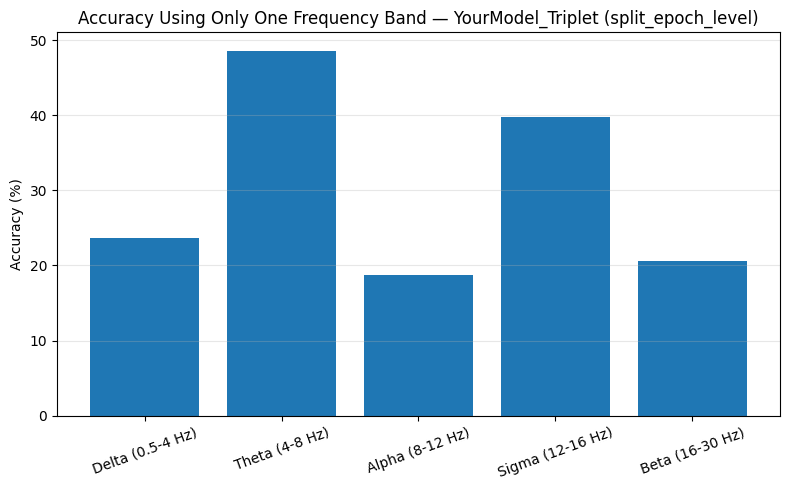

Delta (0.5-4 Hz): mute accuracy = 0.4230
Theta (4-8 Hz): mute accuracy = 0.7852
Alpha (8-12 Hz): mute accuracy = 0.8138
Sigma (12-16 Hz): mute accuracy = 0.8291
Beta (16-30 Hz): mute accuracy = 0.8167


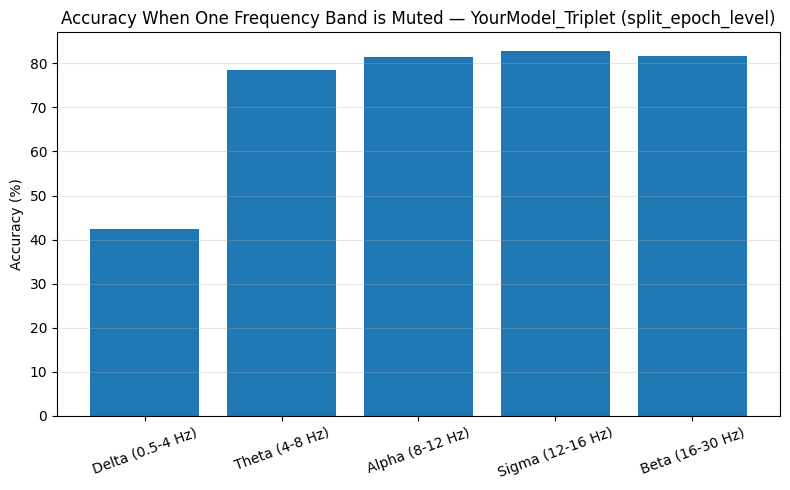

In [16]:
FS = EPOCH_LEN / 30.0
band_defs = {
    'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-12 Hz)': (8, 12), 'Sigma (12-16 Hz)': (12, 16),
    'Beta (16-30 Hz)': (16, 30),
}

def bandstop(X, low, high, fs=FS, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='bandstop')
    return filtfilt(b, a, X, axis=-1)

def bandpass(X, low, high, fs=FS, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, X, axis=-1)

def load_triplet_batch(df_subset):
    X_batch = []
    for _, row in df_subset.iterrows():
        X_prev = np.load(row['filepath_prev']).astype(np.float32)
        X_curr = np.load(row['filepath_curr']).astype(np.float32)
        X_next = np.load(row['filepath_next']).astype(np.float32)
        X_context = np.concatenate([X_prev, X_curr, X_next], axis=-1)
        mean = X_context.mean(axis=1, keepdims=True)
        std = X_context.std(axis=1, keepdims=True)
        X_context = (X_context - mean) / (std + 1e-8)
        X_batch.append(X_context)
    return np.array(X_batch, dtype=np.float32)

val_df_reset = result_epoch['val_df'].reset_index(drop=True)
model_name, split_col = result_epoch['model'], result_epoch['split']

def evaluate_with_band_transform(model, df_val, transform_fn, batch_size=32):
    y_t, y_p = [], []
    for start in range(0, len(df_val), batch_size):
        batch_df = df_val.iloc[start:start+batch_size]
        X_batch = load_triplet_batch(batch_df)
        if transform_fn is not None:
            X_batch = transform_fn(X_batch)
        preds = model.predict(X_batch, batch_size=batch_size, verbose=0)
        y_p.extend(np.argmax(preds, axis=1))
        y_t.extend(batch_df['label_code'].values)
        del X_batch
    return accuracy_score(y_t, y_p)

print(f"\n--- Global Band Sweep: {model_name} ({split_col}) ---")

single_band_acc = {}
for band_name, (low, high) in band_defs.items():
    acc = evaluate_with_band_transform(best_model, val_df_reset, lambda X, l=low, h=high: bandpass(X, l, h))
    single_band_acc[band_name] = acc
    print(f"{band_name}: isolated-band accuracy = {acc:.4f}")

plt.figure(figsize=(8,5))
plt.bar(single_band_acc.keys(), [v*100 for v in single_band_acc.values()])
plt.ylabel('Accuracy (%)'); plt.title(f'Accuracy Using Only One Frequency Band — {model_name} ({split_col})')
plt.xticks(rotation=20); plt.grid(True, axis='y', alpha=0.3); plt.tight_layout(); plt.show()

mute_band_acc = {}
for band_name, (low, high) in band_defs.items():
    acc = evaluate_with_band_transform(best_model, val_df_reset, lambda X, l=low, h=high: bandstop(X, l, h))
    mute_band_acc[band_name] = acc
    print(f"{band_name}: mute accuracy = {acc:.4f}")

plt.figure(figsize=(8,5))
plt.bar(mute_band_acc.keys(), [v*100 for v in mute_band_acc.values()])
plt.ylabel('Accuracy (%)'); plt.title(f'Accuracy When One Frequency Band is Muted — {model_name} ({split_col})')
plt.xticks(rotation=20); plt.grid(True, axis='y', alpha=0.3); plt.tight_layout(); plt.show()

In [25]:
print(val_df_subject.groupby('subject')['group'].first().value_counts())

group
HC     6
ZAN    5
Name: count, dtype: int64


In [26]:
val_df_epoch = result_epoch['val_df'].reset_index(drop=True)
val_df_epoch['group'] = val_df_epoch['subject'].apply(lambda s: 'ZAN' if s in zan_subjects else 'HC')

y_true_e, y_pred_e = result_epoch['y_true'], result_epoch['y_pred']

print(val_df_epoch.groupby('subject')['group'].first().value_counts())
print()

for grp in ['HC', 'ZAN']:
    mask = (val_df_epoch['group'] == grp).values
    if mask.sum() == 0:
        print(f"{grp}: no validation samples in this split")
        continue
    acc = accuracy_score(y_true_e[mask], y_pred_e[mask])
    print(f"{grp} epoch-level accuracy: {acc:.4f} (n={mask.sum()} epochs)")
    print(classification_report(y_true_e[mask], y_pred_e[mask], target_names=CLASS_NAMES, digits=4, zero_division=0))

group
HC     28
ZAN    24
Name: count, dtype: int64

HC epoch-level accuracy: 0.8729 (n=4980 epochs)
              precision    recall  f1-score   support

        Wake     0.8559    0.8632    0.8595       475
          N1     0.7126    0.6071    0.6556       588
          N2     0.9094    0.9112    0.9103      2456
          N3     0.8193    0.8723    0.8450       603
         REM     0.9097    0.9510    0.9299       858

    accuracy                         0.8729      4980
   macro avg     0.8414    0.8410    0.8401      4980
weighted avg     0.8702    0.8729    0.8709      4980

ZAN epoch-level accuracy: 0.8369 (n=4396 epochs)
              precision    recall  f1-score   support

        Wake     0.8365    0.8387    0.8376       781
          N1     0.7284    0.6695    0.6977       593
          N2     0.8470    0.8800    0.8632      1925
          N3     0.8215    0.7456    0.7817       574
         REM     0.9232    0.9656    0.9439       523

    accuracy                       